In [5]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression


ModuleNotFoundError: No module named 'yfinance'

In [2]:
#Lista de Acciones
B_Acciones = ['AAL','AAPL','ABBV','ABNB','AC','AFRM','AGNC','ALFAA.MX','ALPEKA.MX','ALSEA.MX','AMAT','AMD','AMXB.MX','AMZN','APA','ASURB.MX','ATER','ATOS','AVGO','AXP','BA','BABA','BAC','BBAJIOO.MX','BIMBOA.MX','BMY','BNGO','BOLSAA.MX','BRKB.MX','BYND','C','CAT','CCL1N.MX','CEMEXCPO.MX','CHDRAUIB.MX','CLF','COST','CPE','CRM','CSCO','CUERVO.MX','CVS','CVX','DAL','DIS','DVN','ELEKTRA.MX','ETSY','F','FANG','FCX','FDX','FEMSAUBD.MX','FIBRAMQ12.MX','FIBRAPL14.MX','FSLR','FUBO','FUNO11.MX','GAPB.MX','GCARSOA1.MX','GCC','GE','GENTERA.MX','GFINBURO.MX','GFNORTEO.MX','GILD','GM','GME','GMEXICOB.MX','GOLD','GOOGL','GRUMAB.MX','HD','INTC','JNJ','JPM','KIMBERA.MX','KO','KOFUBL.MX','LABB.MX','LASITEB-1.MX','LCID','LIVEPOLC-1.MX','LLY','LUV','LVS','LYFT','MA','MARA','MCD','MEGACPO.MX','MELI','META','MGM','MRK','MRNA','MRO','MSFT','MU','NCLH','NFLX','NKE','NKLA','NU','NVAX','NVDA','OMAB','ORBIA.MX','ORCL','OXY1.MX','PARA','PBR','PE&OLES.MX','PEP','PFE','PG','PINFRA.MX','PINS','PLTR','PYPL','Q.MX','QCOM','RA','RCL','RIOT','RIVN','ROKU','SBUX','SHOP','SITES1A-1.MX','SKLZ','SOFI','SPCE','SQ','T','TAL','TERRA13.MX','TGT','TLEVISACPO.MX','TMO','TSLA','TSM','TWLO','TX','UAL','UBER','UNH','UPST','V','VESTA.MX','VOLARA.MX','VZ','WALMEX.MX','WFC','WISH','WMT','WYNN','X','XOM','ZM']
#usar funcion para bajar la data
Base = yf.download(B_Acciones, start="2013-01-01", end="2024-02-06")

[*********************100%***********************]  160 of 160 completed


In [3]:
# Se utiliza este método para refrescar el valor previo
Base=Base.ffill()

In [4]:
# para agrupar la información y poder visualizarla en Excel
Base.to_excel('Base2.xlsx')

In [5]:
Info_acciones = Base.Close

In [6]:
#se rellenan valores con ceros para campos que pudieran quedar sin información
Info_acciones = Info_acciones.fillna(0)

In [7]:
#calcular rendimiento
Rendimiento = (Info_acciones - Info_acciones.shift(1))/ Info_acciones.shift(1)
Rendimiento = Rendimiento.fillna(0)

In [8]:
#Se agrega un columna de año para poder realizar más adelante una agrupación por este campo
Info_acciones['Año'] = Info_acciones.index.year



In [9]:
# se ordenan las columnas para poder dejar la columna año al principio
Info_acciones = pd.DataFrame.reindex(Info_acciones,columns=['Año','AAL','AAPL','ABBV','ABNB','AC','AFRM','AGNC','ALFAA.MX','ALPEKA.MX','ALSEA.MX','AMAT','AMD','AMXB.MX','AMZN','APA','ASURB.MX','ATER','ATOS','AVGO','AXP','BA','BABA','BAC','BBAJIOO.MX','BIMBOA.MX','BMY','BNGO','BOLSAA.MX','BRKB.MX','BYND','C','CAT','CCL1N.MX','CEMEXCPO.MX','CHDRAUIB.MX','CLF','COST','CPE','CRM','CSCO','CUERVO.MX','CVS','CVX','DAL','DIS','DVN','ELEKTRA.MX','ETSY','F','FANG','FCX','FDX','FEMSAUBD.MX','FIBRAMQ12.MX','FIBRAPL14.MX','FSLR','FUBO','FUNO11.MX','GAPB.MX','GCARSOA1.MX','GCC','GE','GENTERA.MX','GFINBURO.MX','GFNORTEO.MX','GILD','GM','GME','GMEXICOB.MX','GOLD','GOOGL','GRUMAB.MX','HD','INTC','JNJ','JPM','KIMBERA.MX','KO','KOFUBL.MX','LABB.MX','LASITEB-1.MX','LCID','LIVEPOLC-1.MX','LLY','LUV','LVS','LYFT','MA','MARA','MCD','MEGACPO.MX','MELI','META','MGM','MRK','MRNA','MRO','MSFT','MU','NCLH','NFLX','NKE','NKLA','NU','NVAX','NVDA','OMAB','ORBIA.MX','ORCL','OXY1.MX','PARA','PBR','PE&OLES.MX','PEP','PFE','PG','PINFRA.MX','PINS','PLTR','PYPL','Q.MX','QCOM','RA','RCL','RIOT','RIVN','ROKU','SBUX','SHOP','SITES1A-1.MX','SKLZ','SOFI','SPCE','SQ','T','TAL','TERRA13.MX','TGT','TLEVISACPO.MX','TMO','TSLA','TSM','TWLO','TX','UAL','UBER','UNH','UPST','V','VESTA.MX','VOLARA.MX','VZ','WALMEX.MX','WFC','WISH','WMT','WYNN','X','XOM','ZM'])

In [10]:
#de igual maneral para los rendimientos le agregamos una columna para agrupar.
Rendimiento['Año'] = Rendimiento.index.year

In [11]:
#se ordenan los datos para el rendimiento.
Rendimiento = pd.DataFrame.reindex(Rendimiento,columns=['Año','AAL','AAPL','ABBV','ABNB','AC','AFRM','AGNC','ALFAA.MX','ALPEKA.MX','ALSEA.MX','AMAT','AMD','AMXB.MX','AMZN','APA','ASURB.MX','ATER','ATOS','AVGO','AXP','BA','BABA','BAC','BBAJIOO.MX','BIMBOA.MX','BMY','BNGO','BOLSAA.MX','BRKB.MX','BYND','C','CAT','CCL1N.MX','CEMEXCPO.MX','CHDRAUIB.MX','CLF','COST','CPE','CRM','CSCO','CUERVO.MX','CVS','CVX','DAL','DIS','DVN','ELEKTRA.MX','ETSY','F','FANG','FCX','FDX','FEMSAUBD.MX','FIBRAMQ12.MX','FIBRAPL14.MX','FSLR','FUBO','FUNO11.MX','GAPB.MX','GCARSOA1.MX','GCC','GE','GENTERA.MX','GFINBURO.MX','GFNORTEO.MX','GILD','GM','GME','GMEXICOB.MX','GOLD','GOOGL','GRUMAB.MX','HD','INTC','JNJ','JPM','KIMBERA.MX','KO','KOFUBL.MX','LABB.MX','LASITEB-1.MX','LCID','LIVEPOLC-1.MX','LLY','LUV','LVS','LYFT','MA','MARA','MCD','MEGACPO.MX','MELI','META','MGM','MRK','MRNA','MRO','MSFT','MU','NCLH','NFLX','NKE','NKLA','NU','NVAX','NVDA','OMAB','ORBIA.MX','ORCL','OXY1.MX','PARA','PBR','PE&OLES.MX','PEP','PFE','PG','PINFRA.MX','PINS','PLTR','PYPL','Q.MX','QCOM','RA','RCL','RIOT','RIVN','ROKU','SBUX','SHOP','SITES1A-1.MX','SKLZ','SOFI','SPCE','SQ','T','TAL','TERRA13.MX','TGT','TLEVISACPO.MX','TMO','TSLA','TSM','TWLO','TX','UAL','UBER','UNH','UPST','V','VESTA.MX','VOLARA.MX','VZ','WALMEX.MX','WFC','WISH','WMT','WYNN','X','XOM','ZM'])


In [12]:
#se realiza una agrupación por año
R_anuales = Rendimiento.groupby('Año').sum()


In [13]:
#se realiza una suma de los rendimientos 
Anual= R_anuales.sum()

In [14]:
#ordenar y filtrar los 10 con mayor rendimiento
Top =Anual.sort_values(axis=0,ascending=False).head(10)

In [15]:
#pasarlos a una lista
Top_A= Top.index.tolist()

In [16]:
Top_A

['MARA', 'NVDA', 'TSLA', 'AMD', 'RIOT', 'GME', 'NFLX', 'SHOP', 'TAL', 'MELI']

[*********************100%***********************]  1 of 1 completed


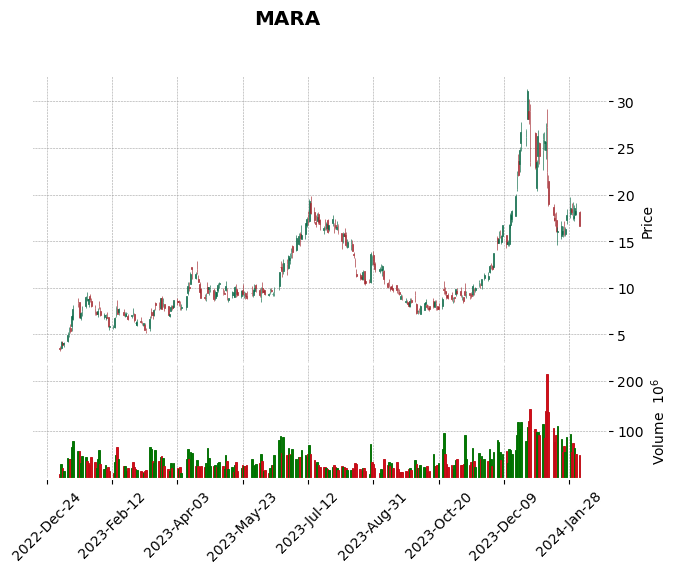

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


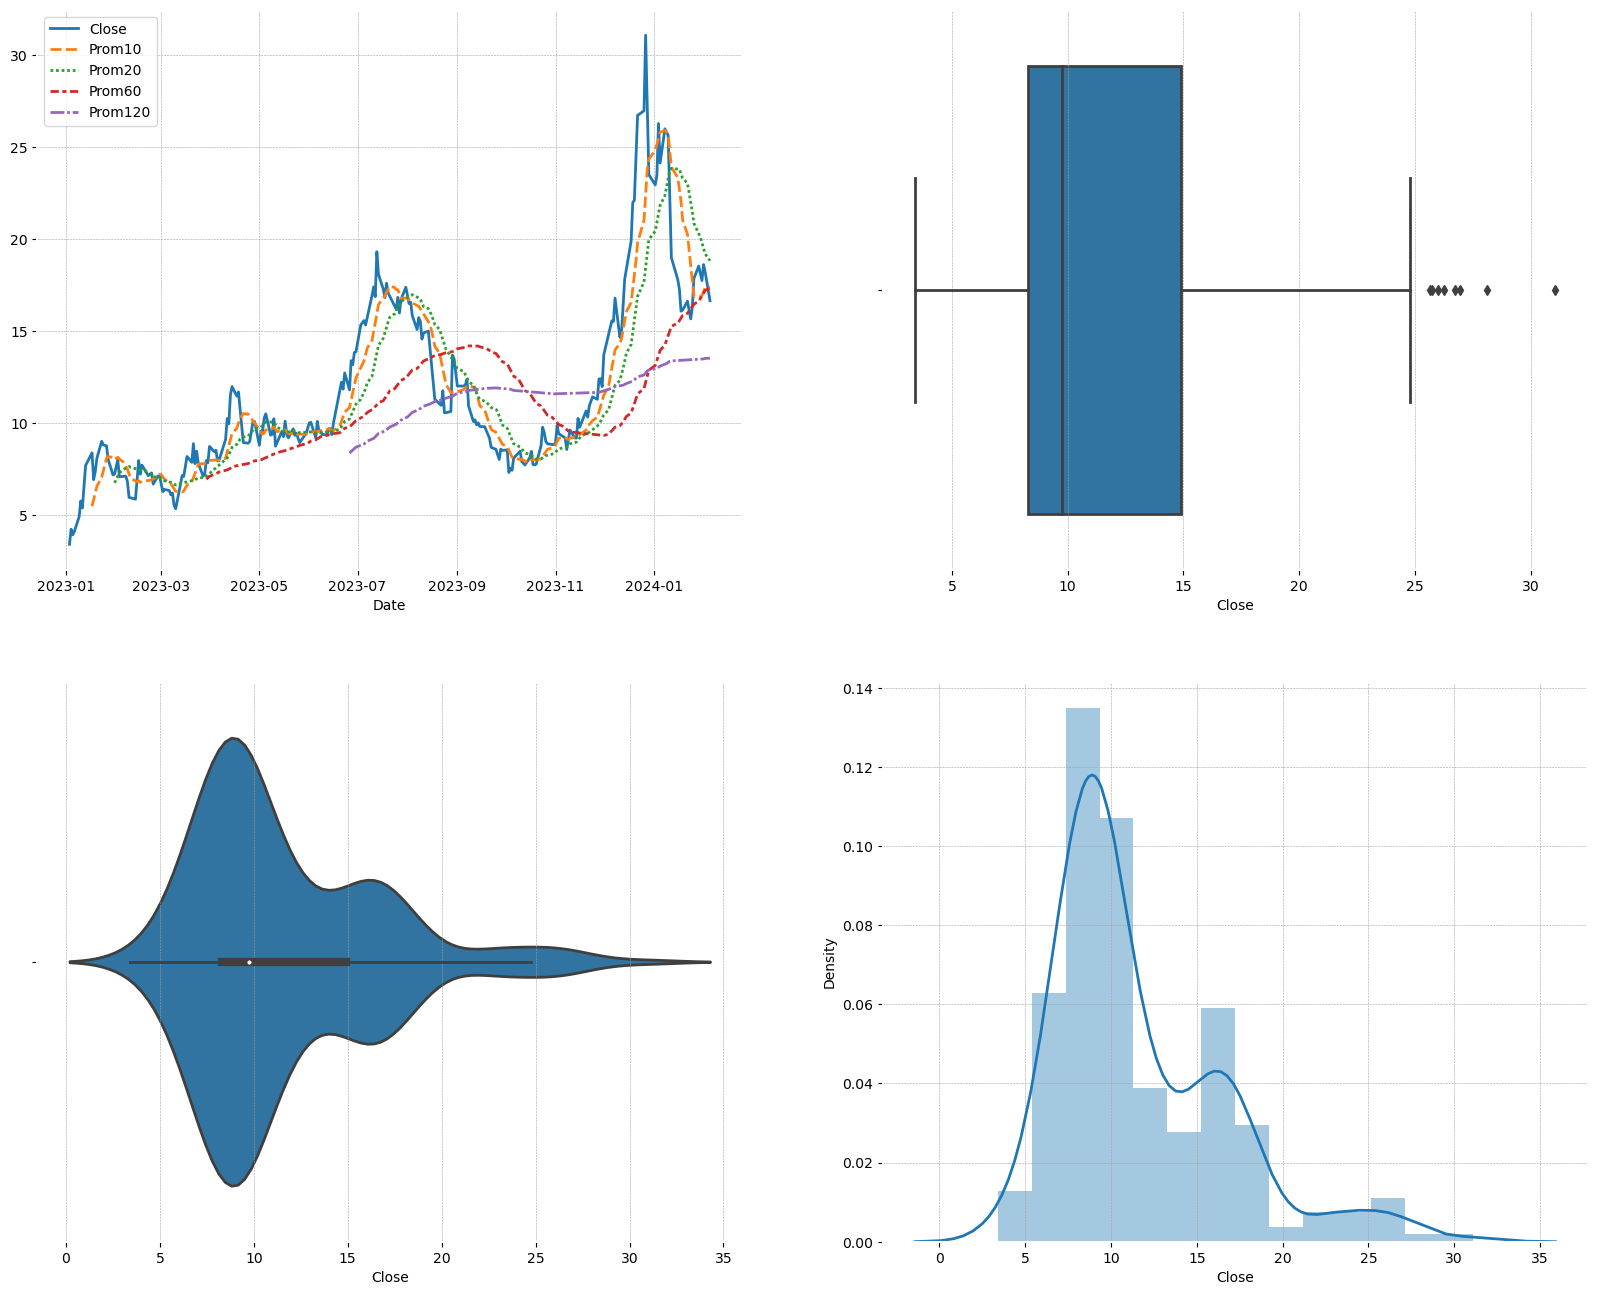

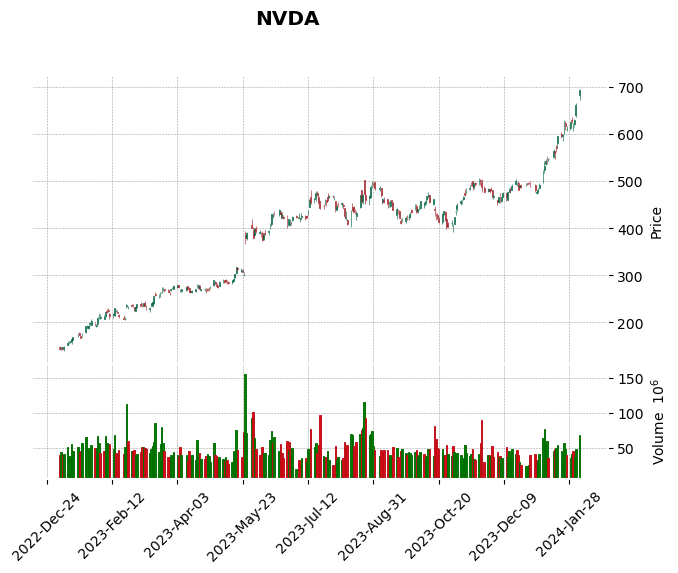

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


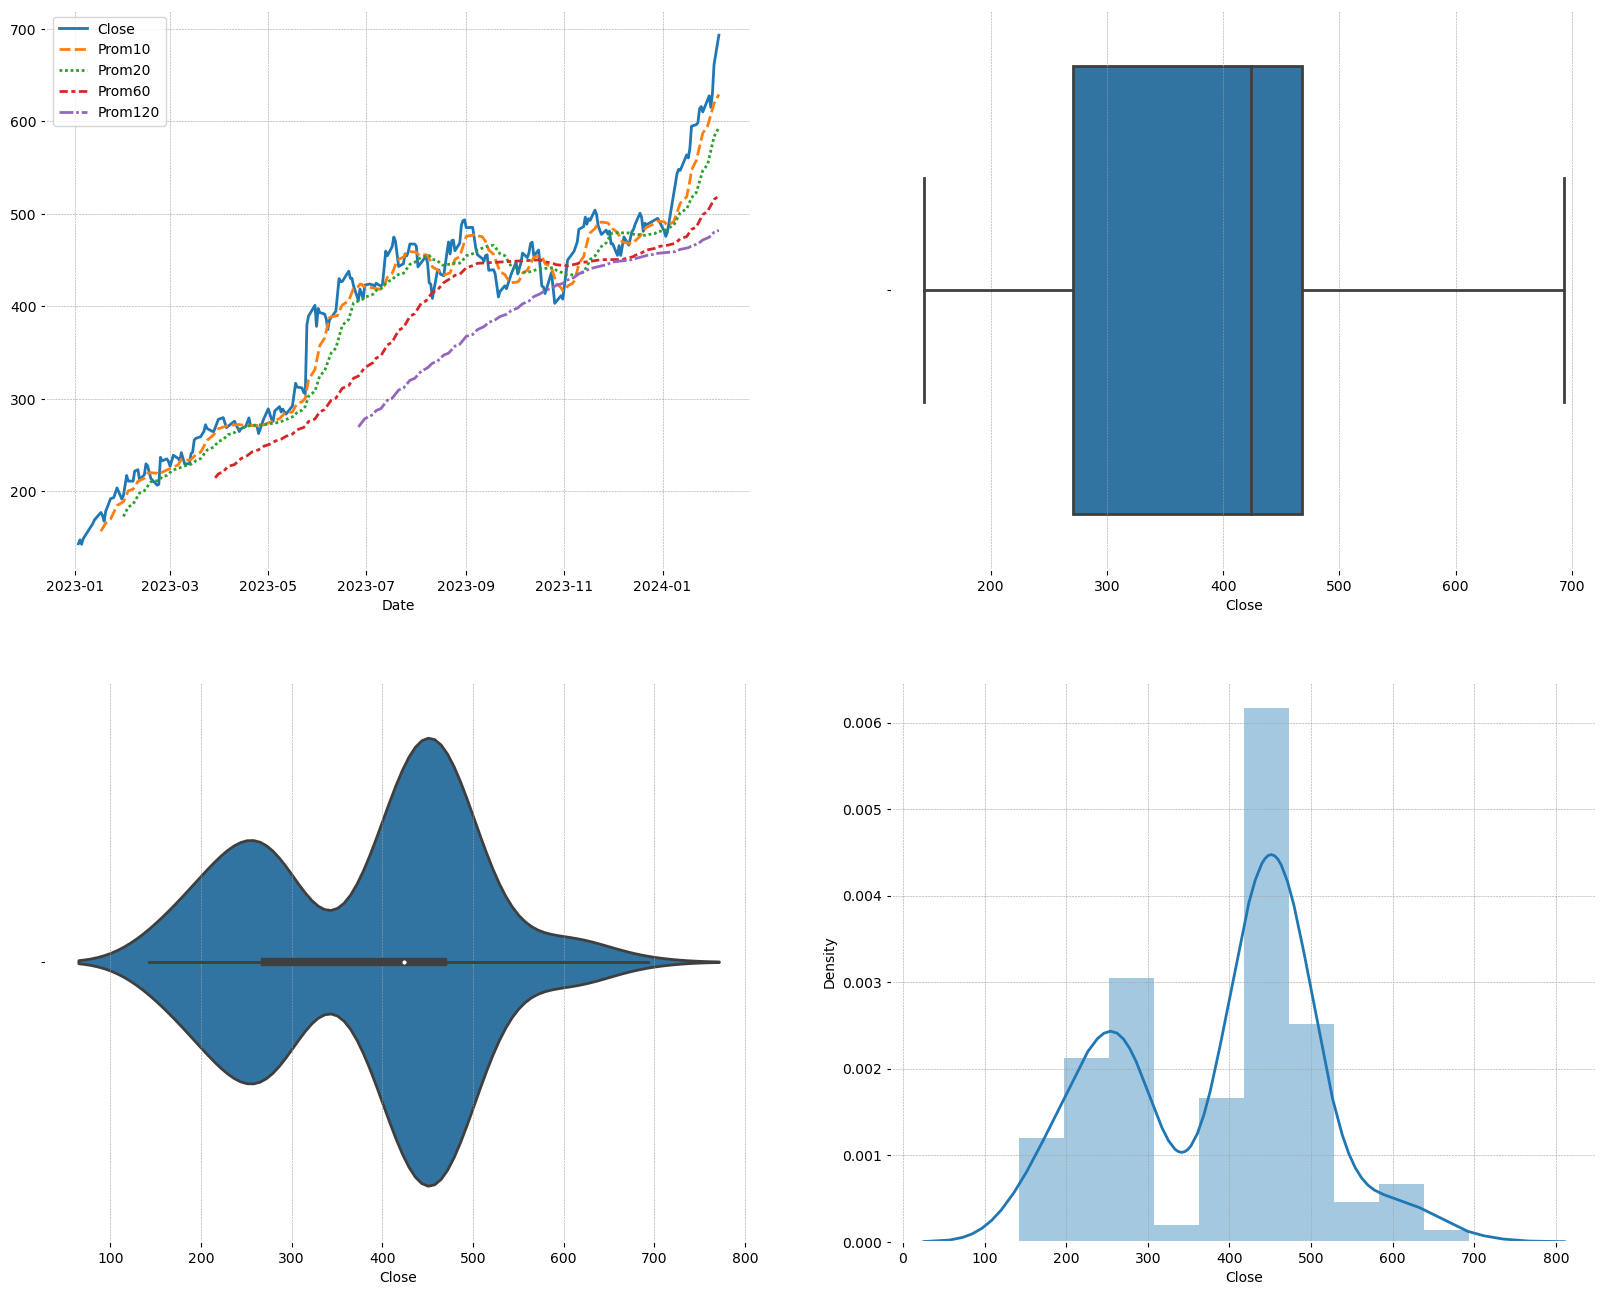

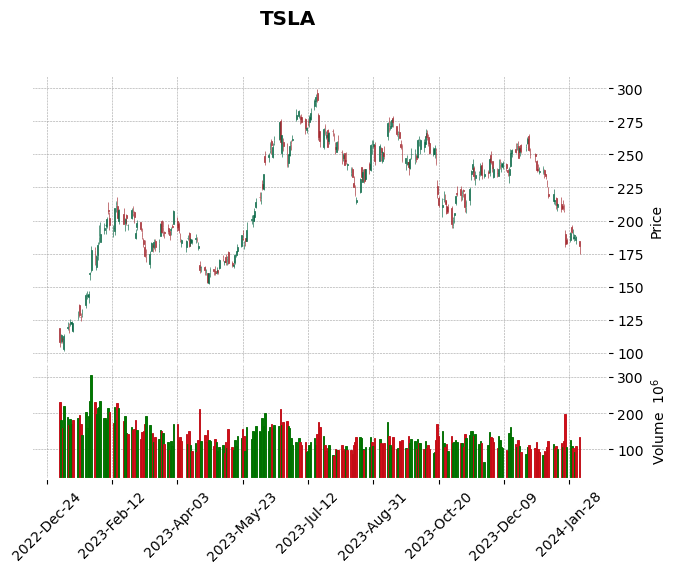

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


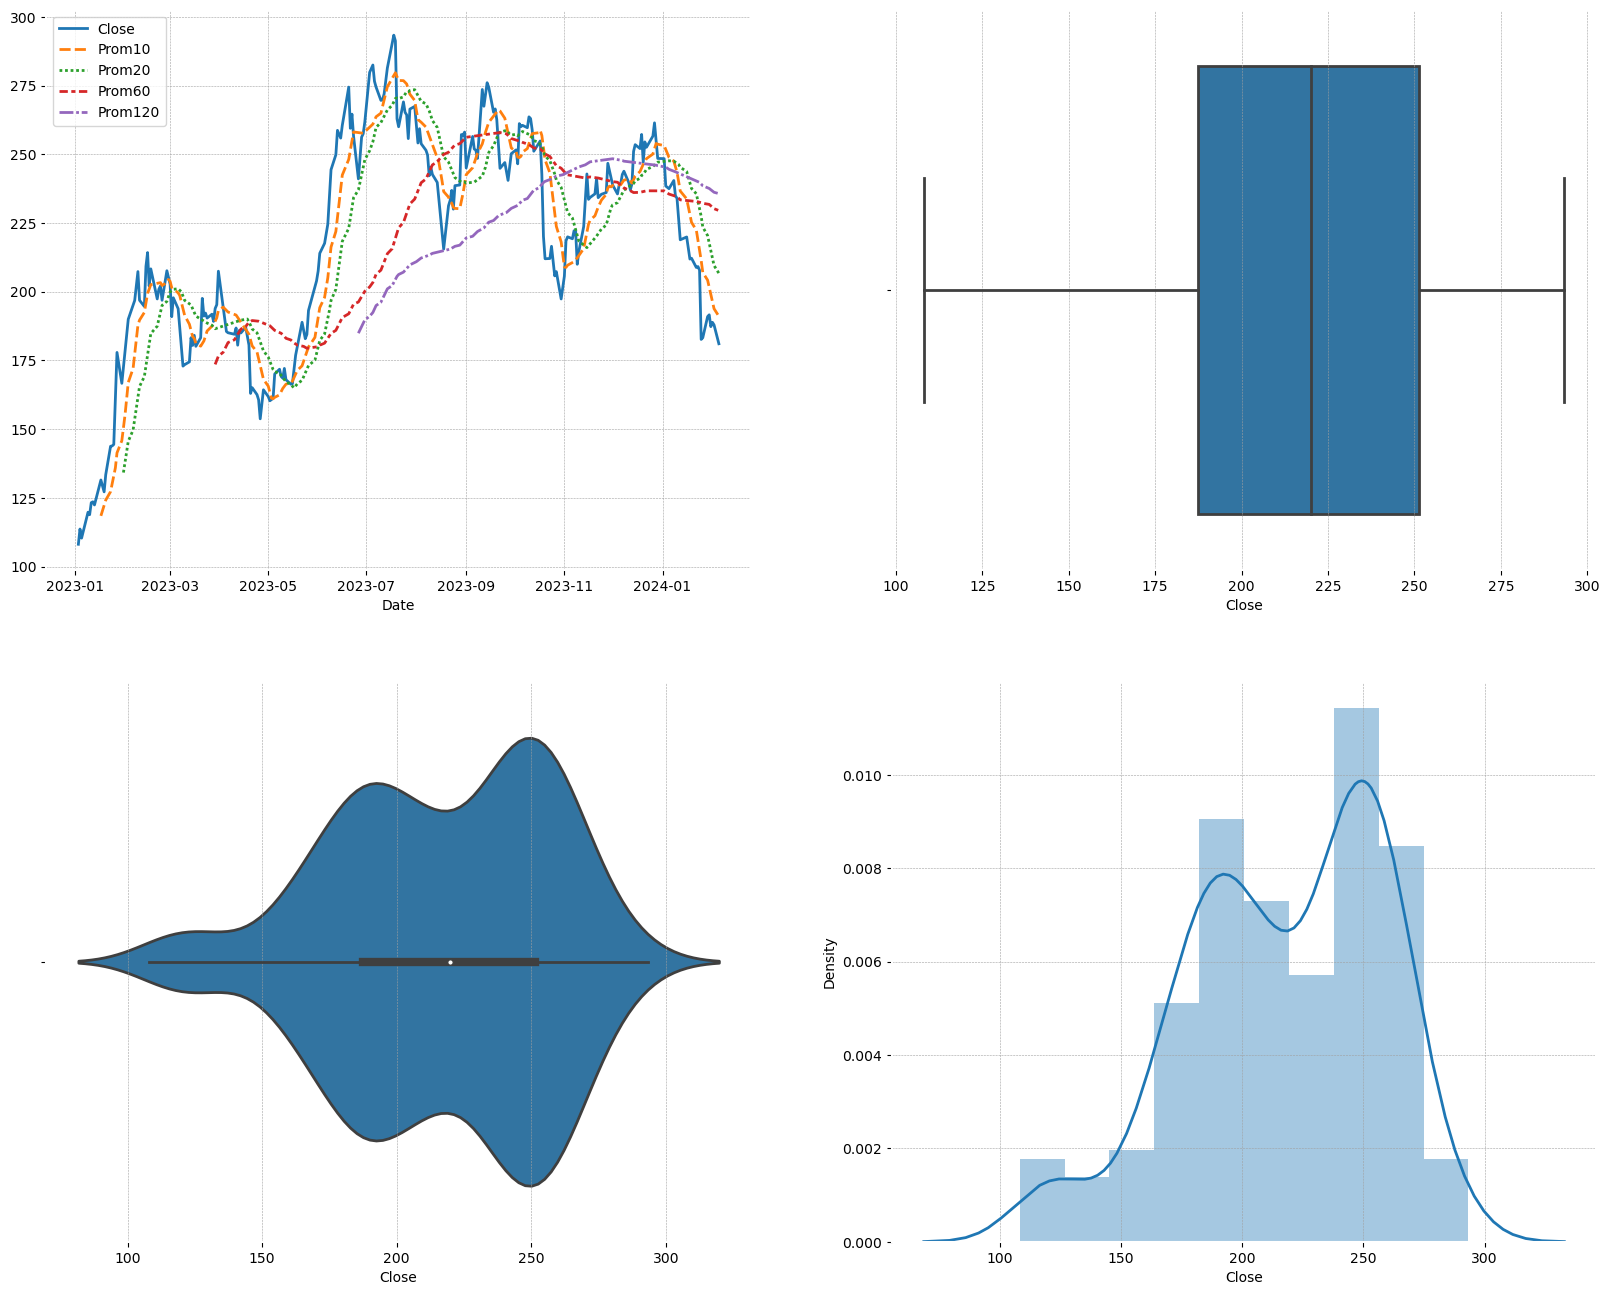

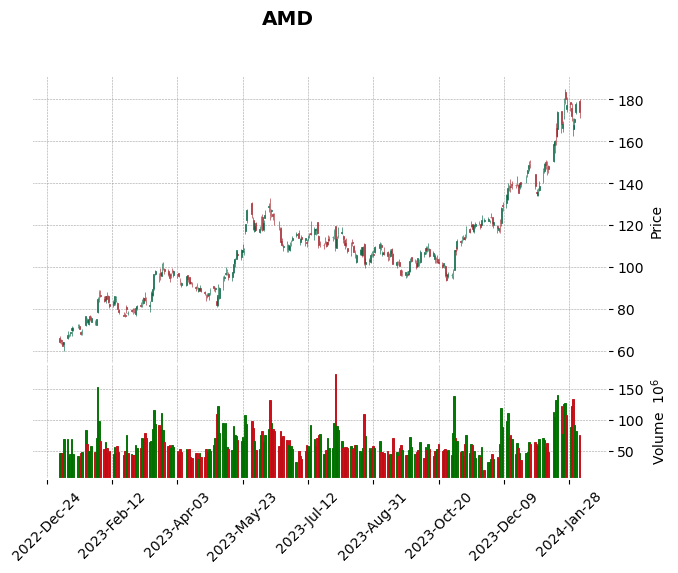

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


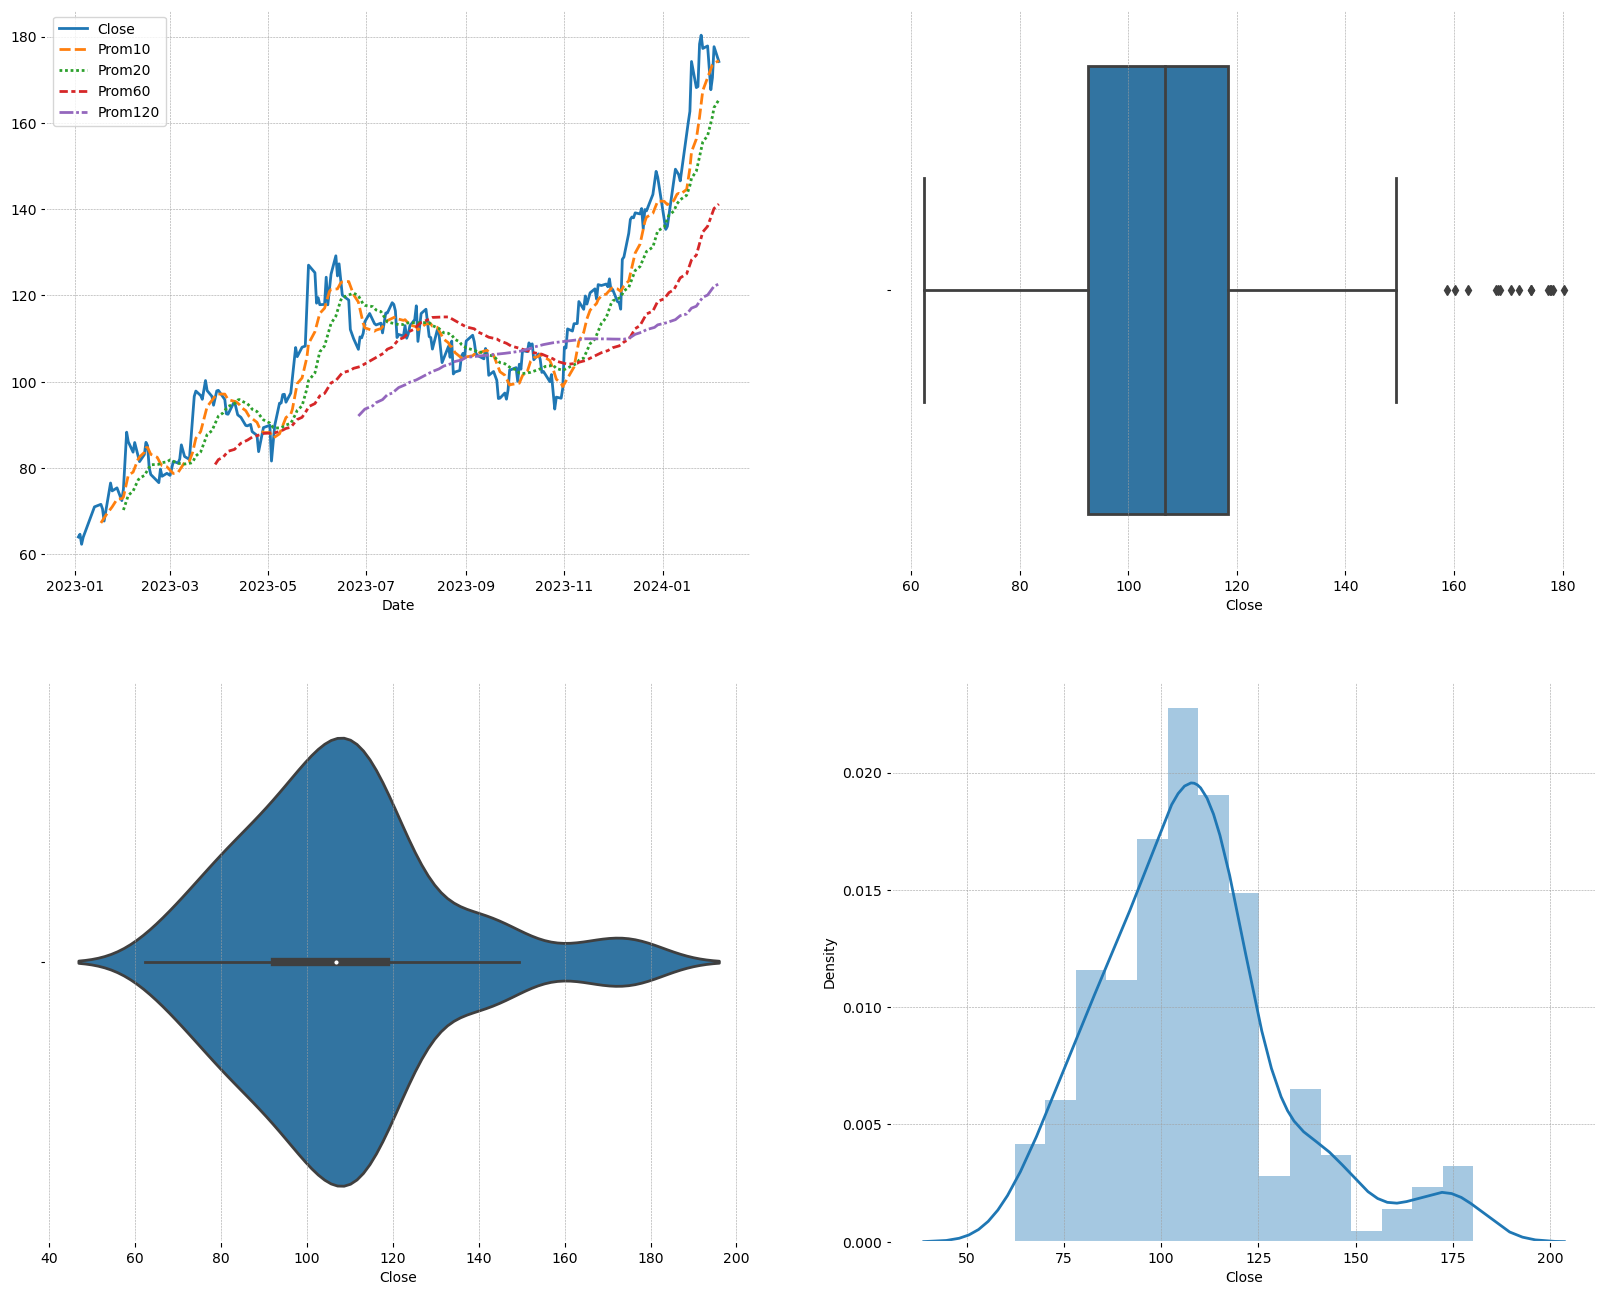

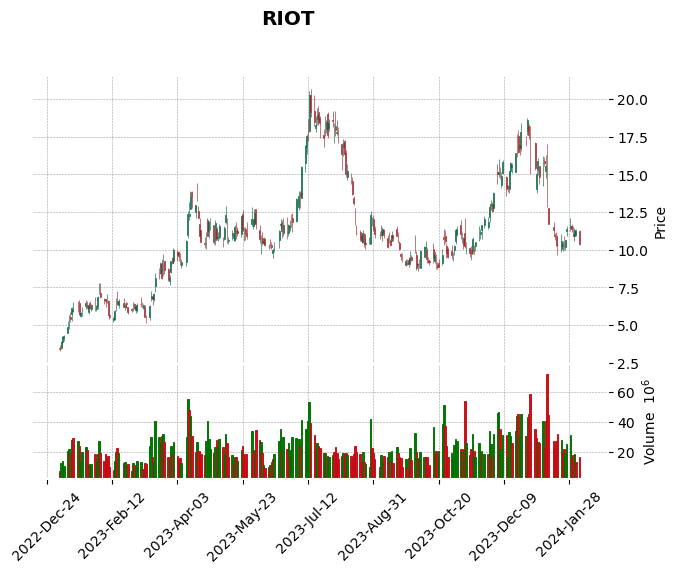

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


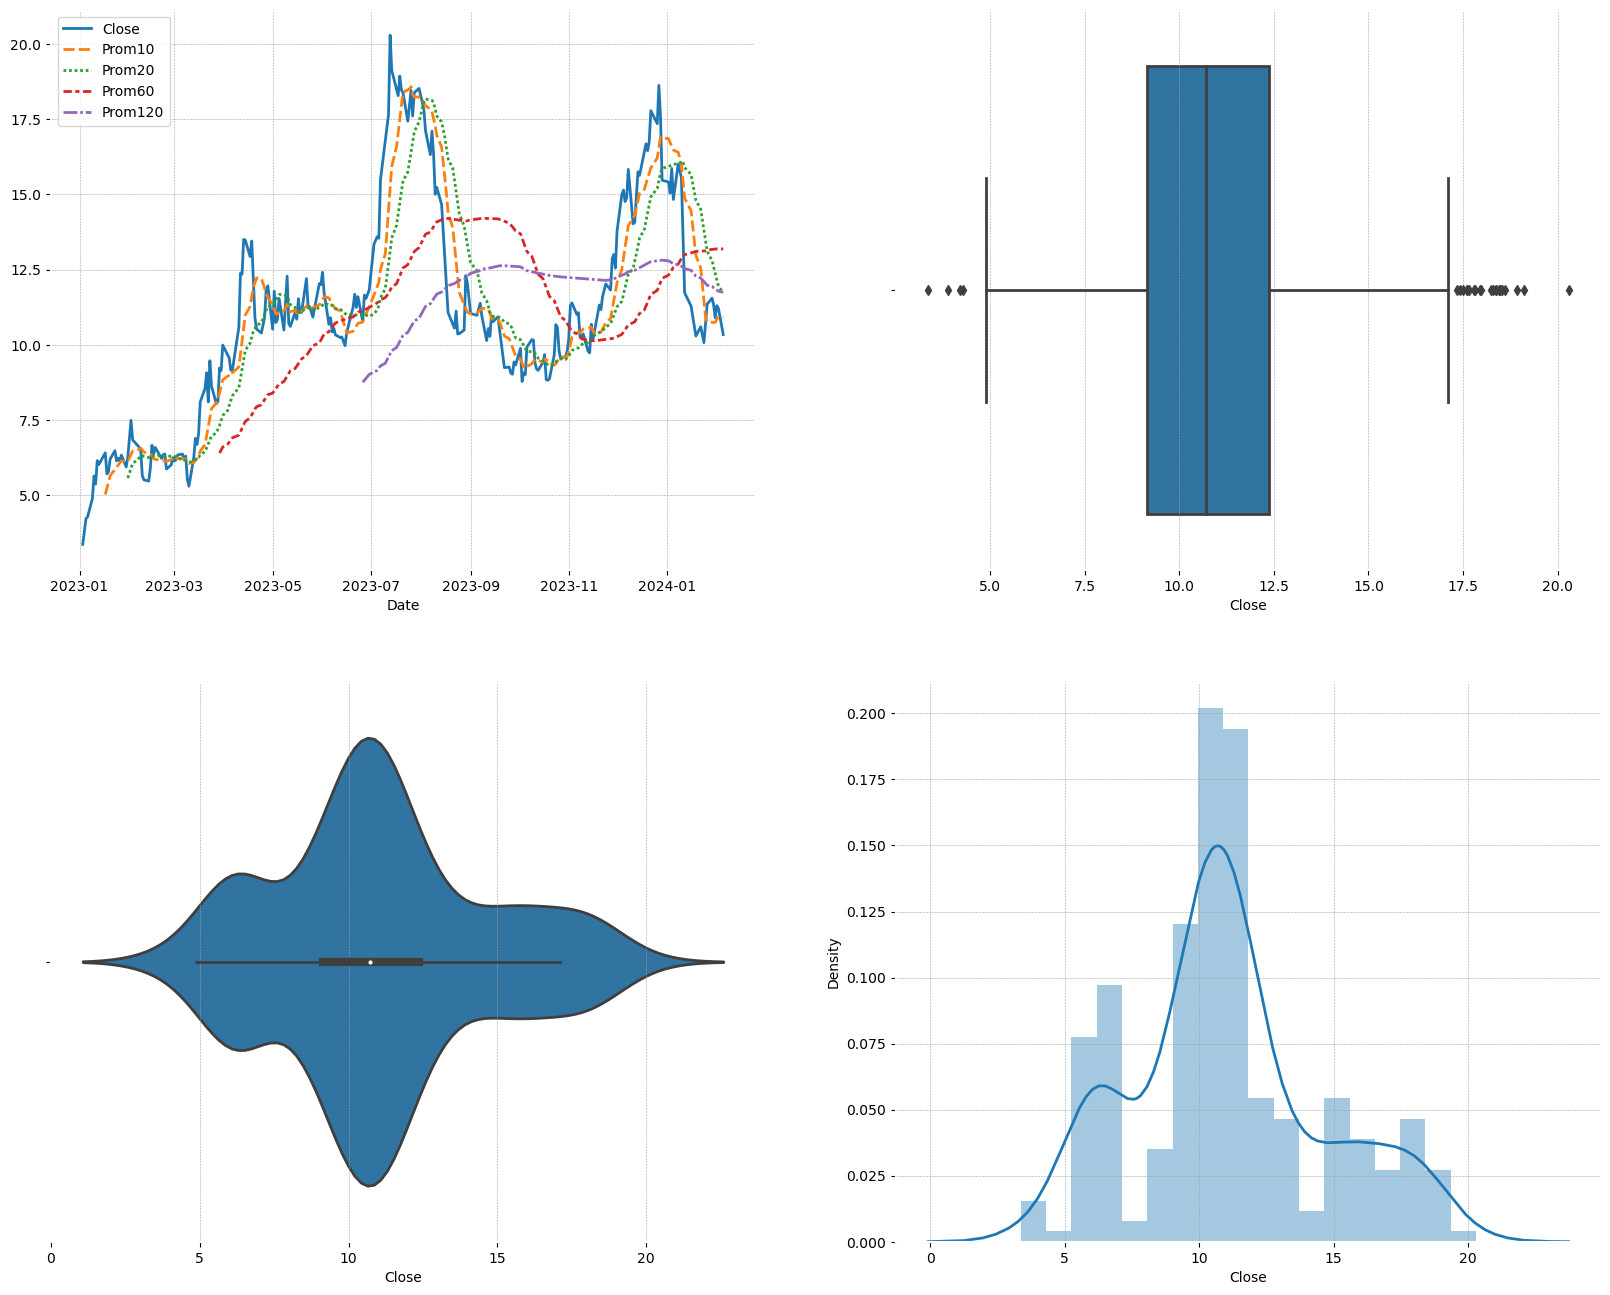

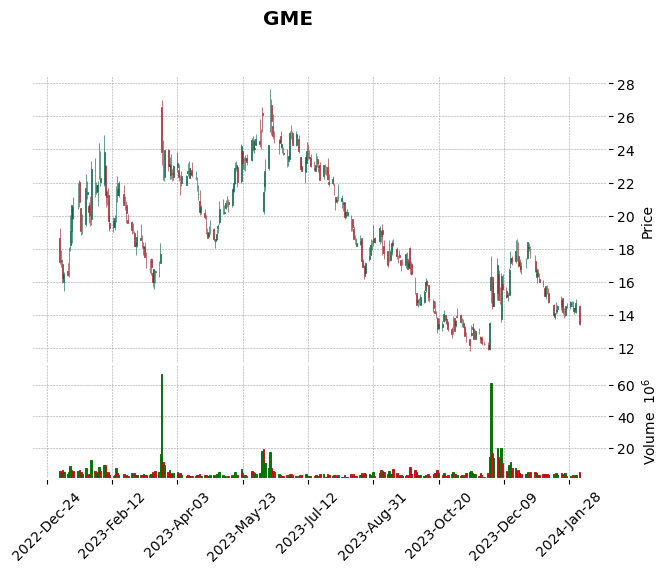

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


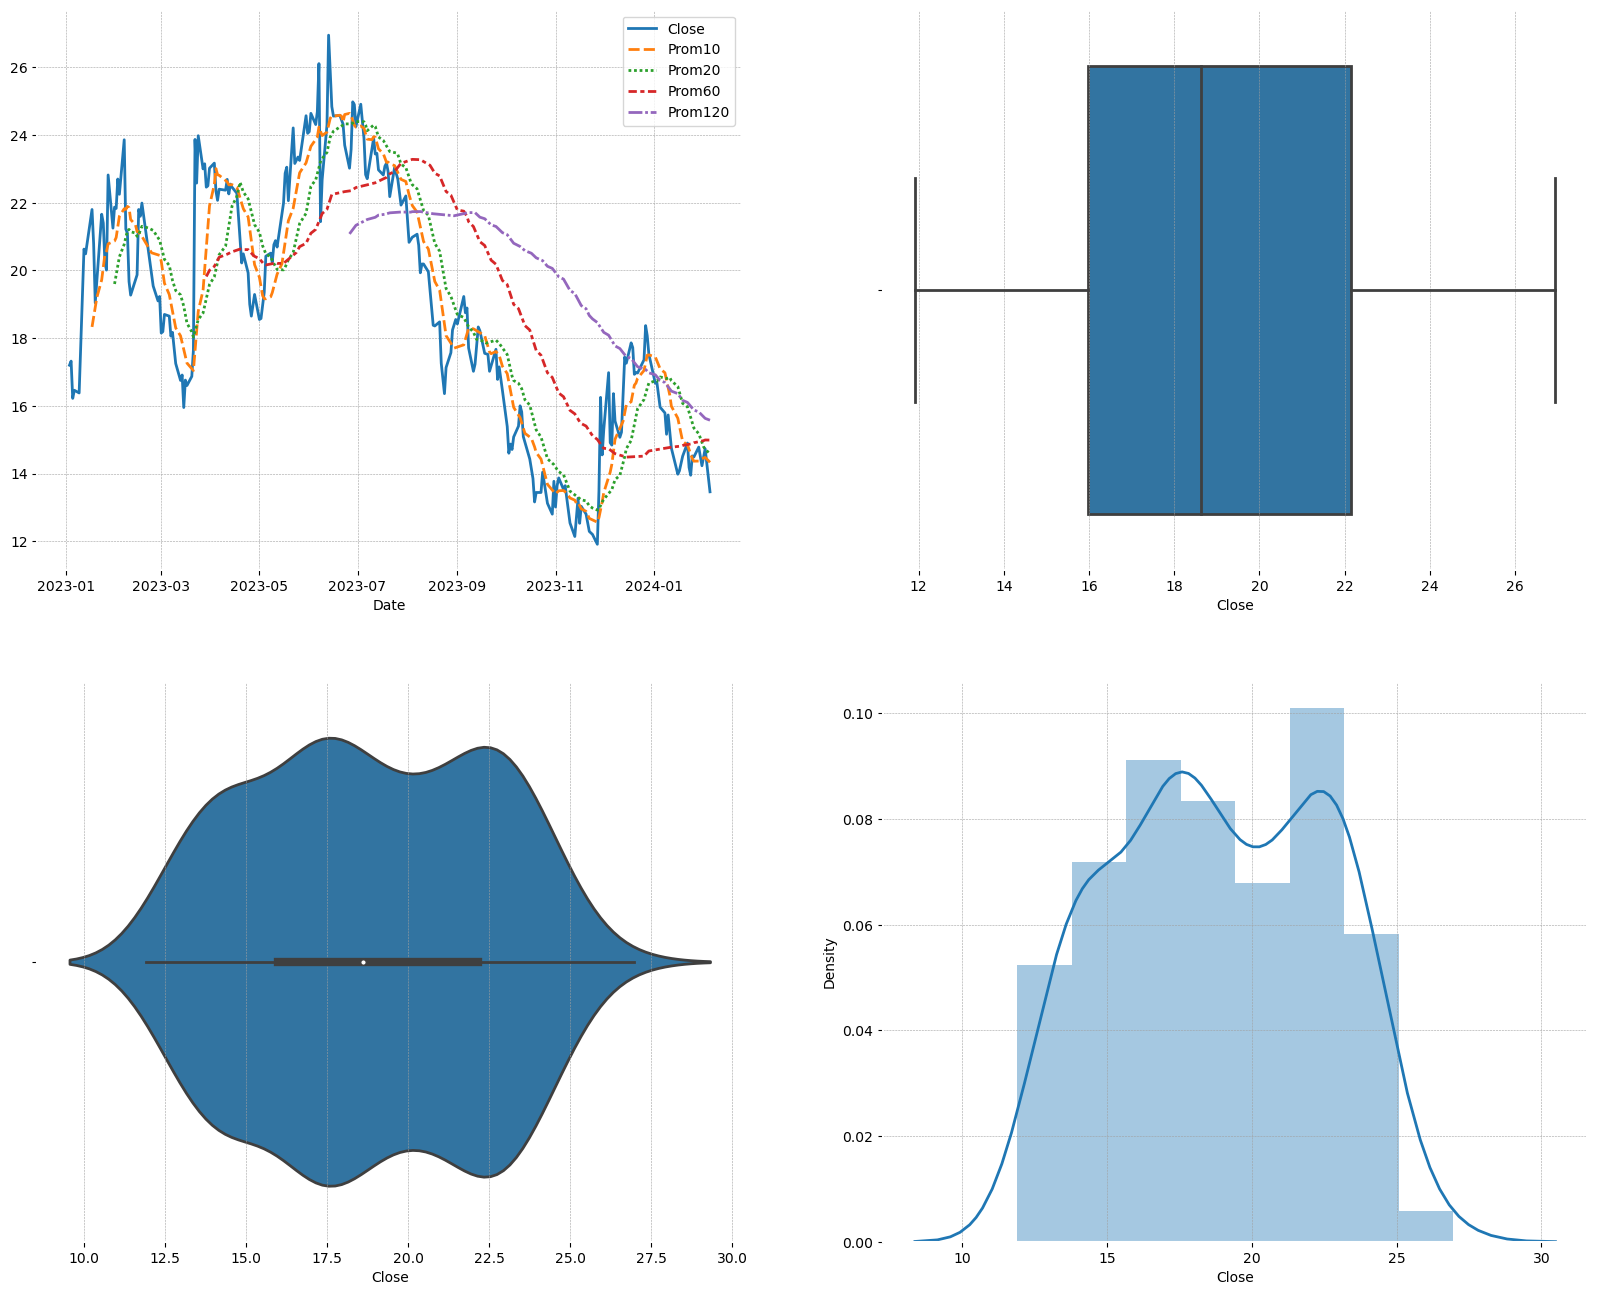

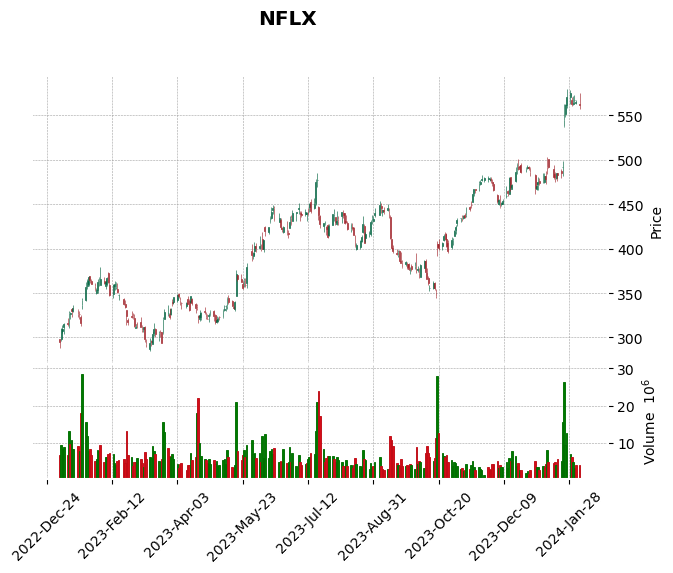

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


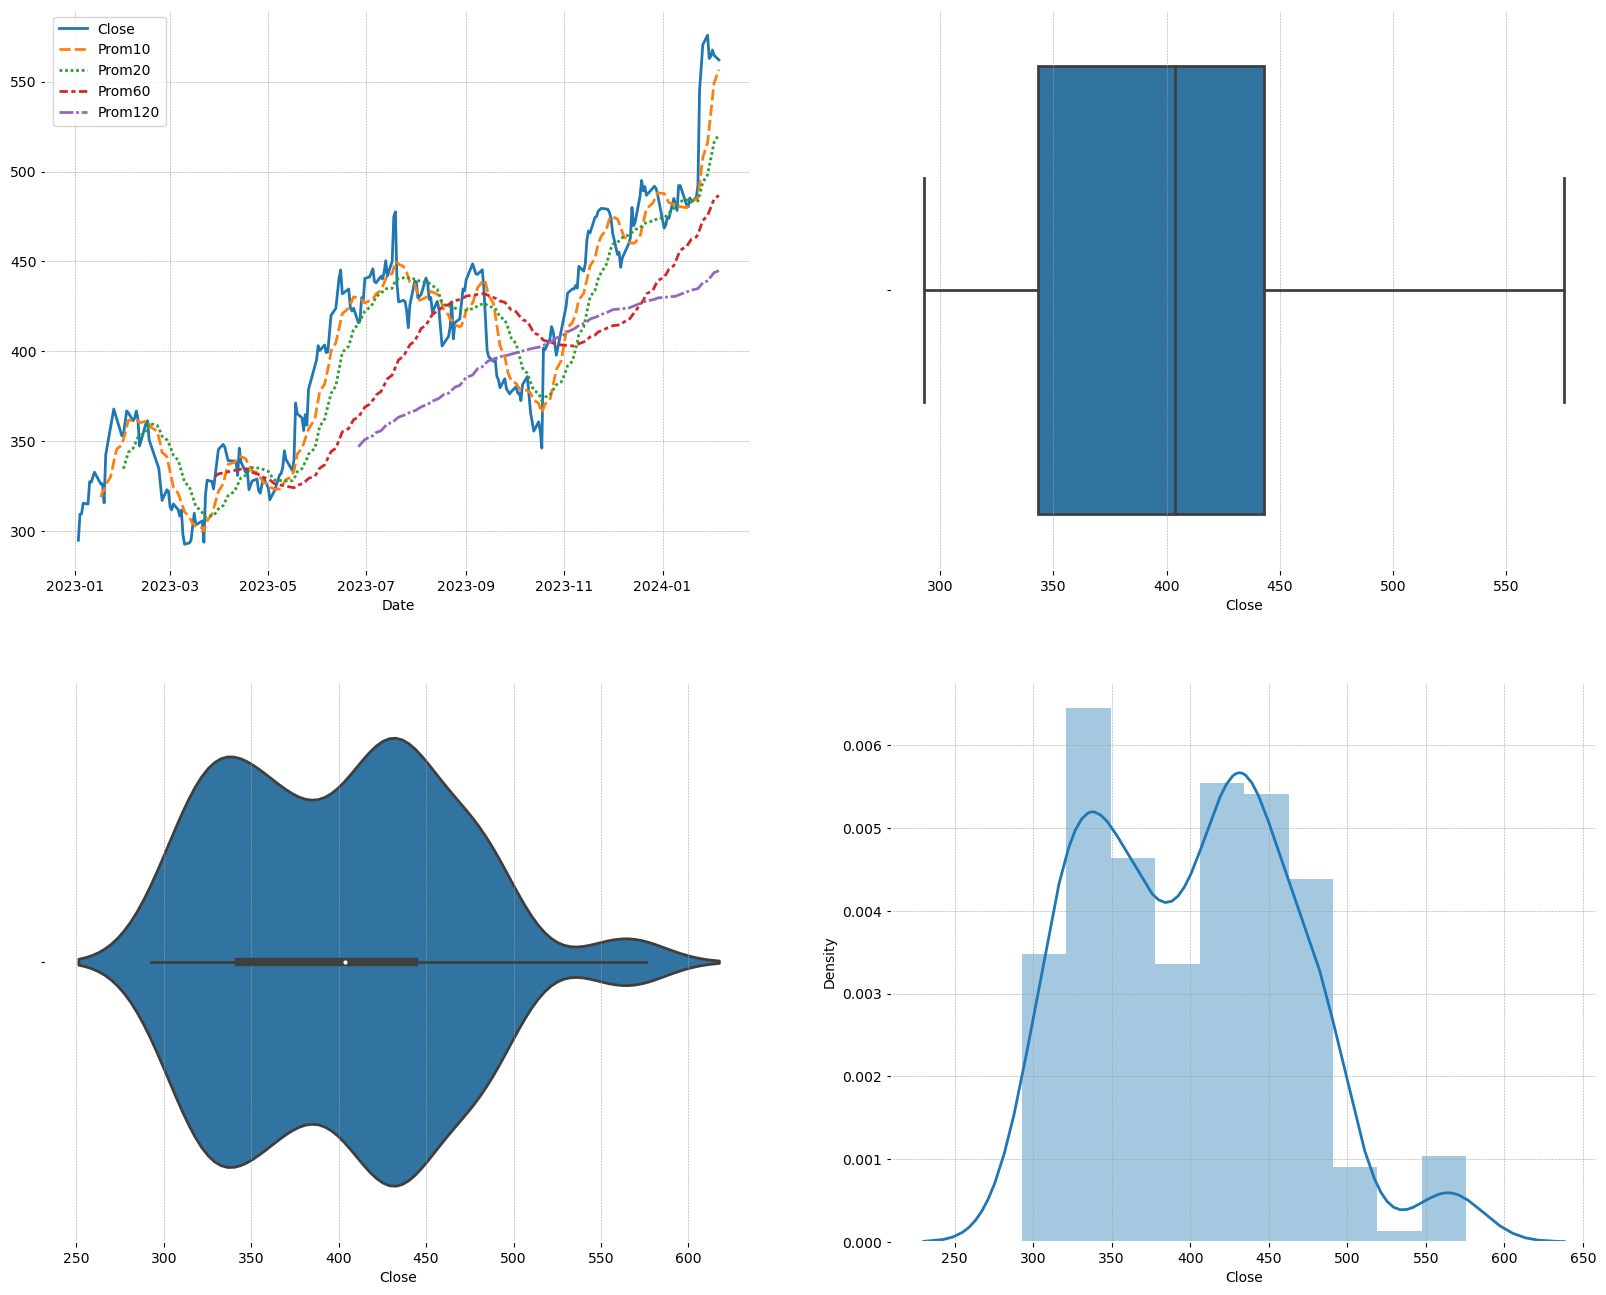

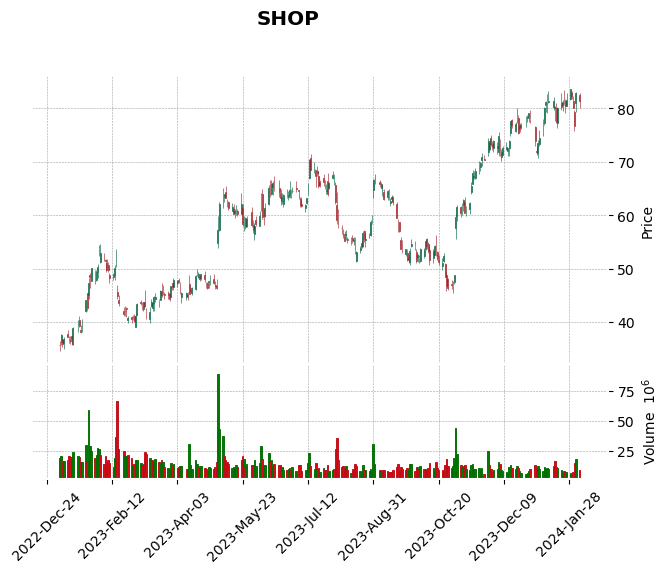

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


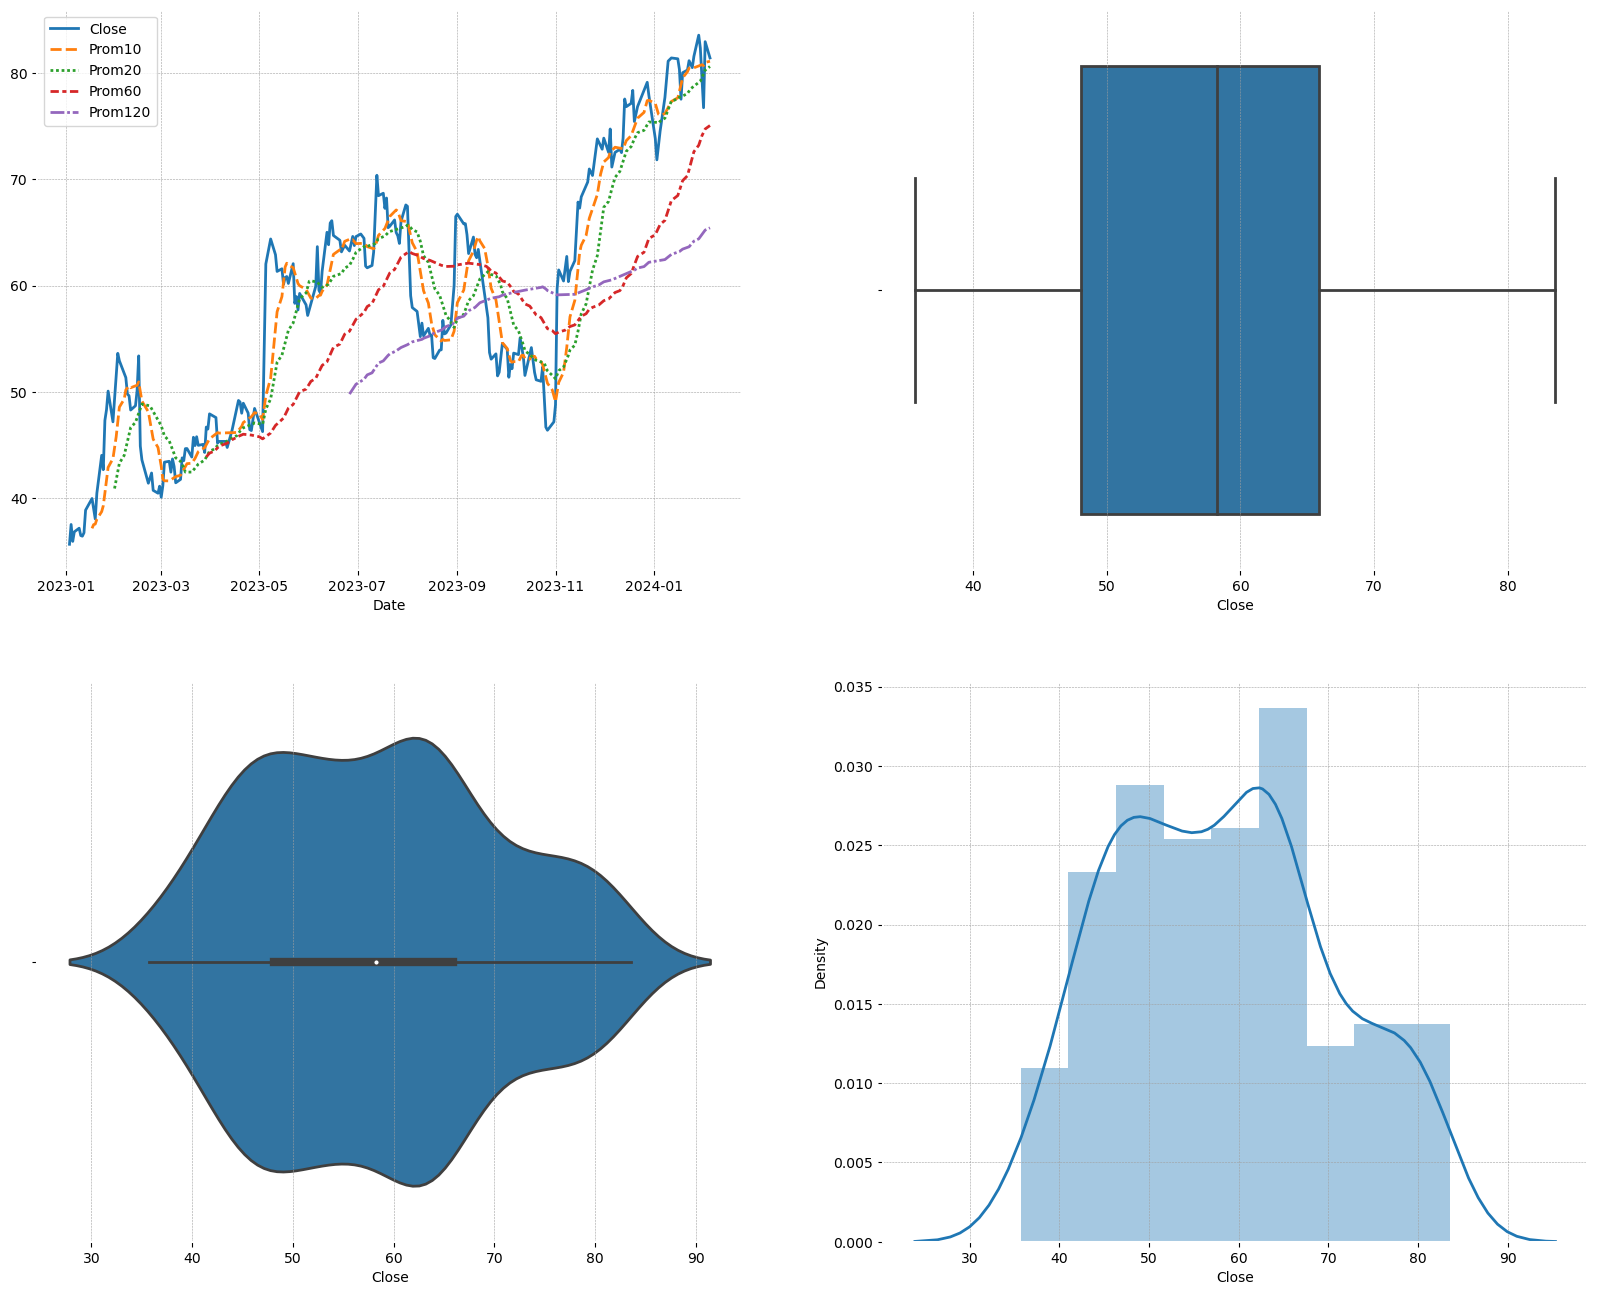

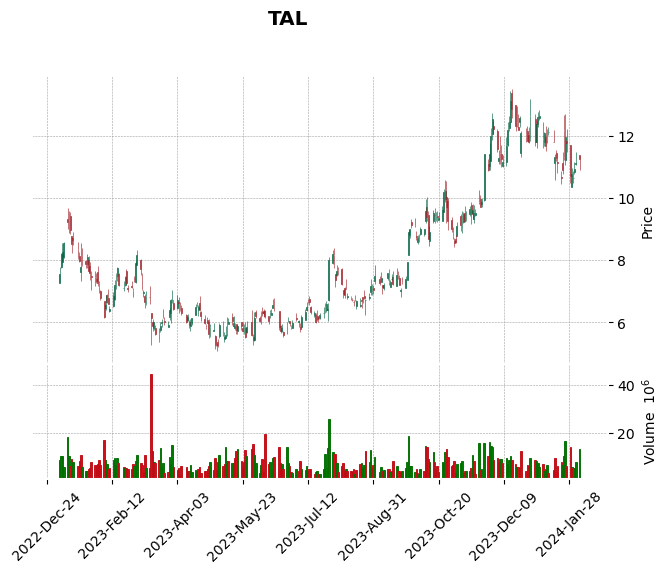

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


[*********************100%***********************]  1 of 1 completed


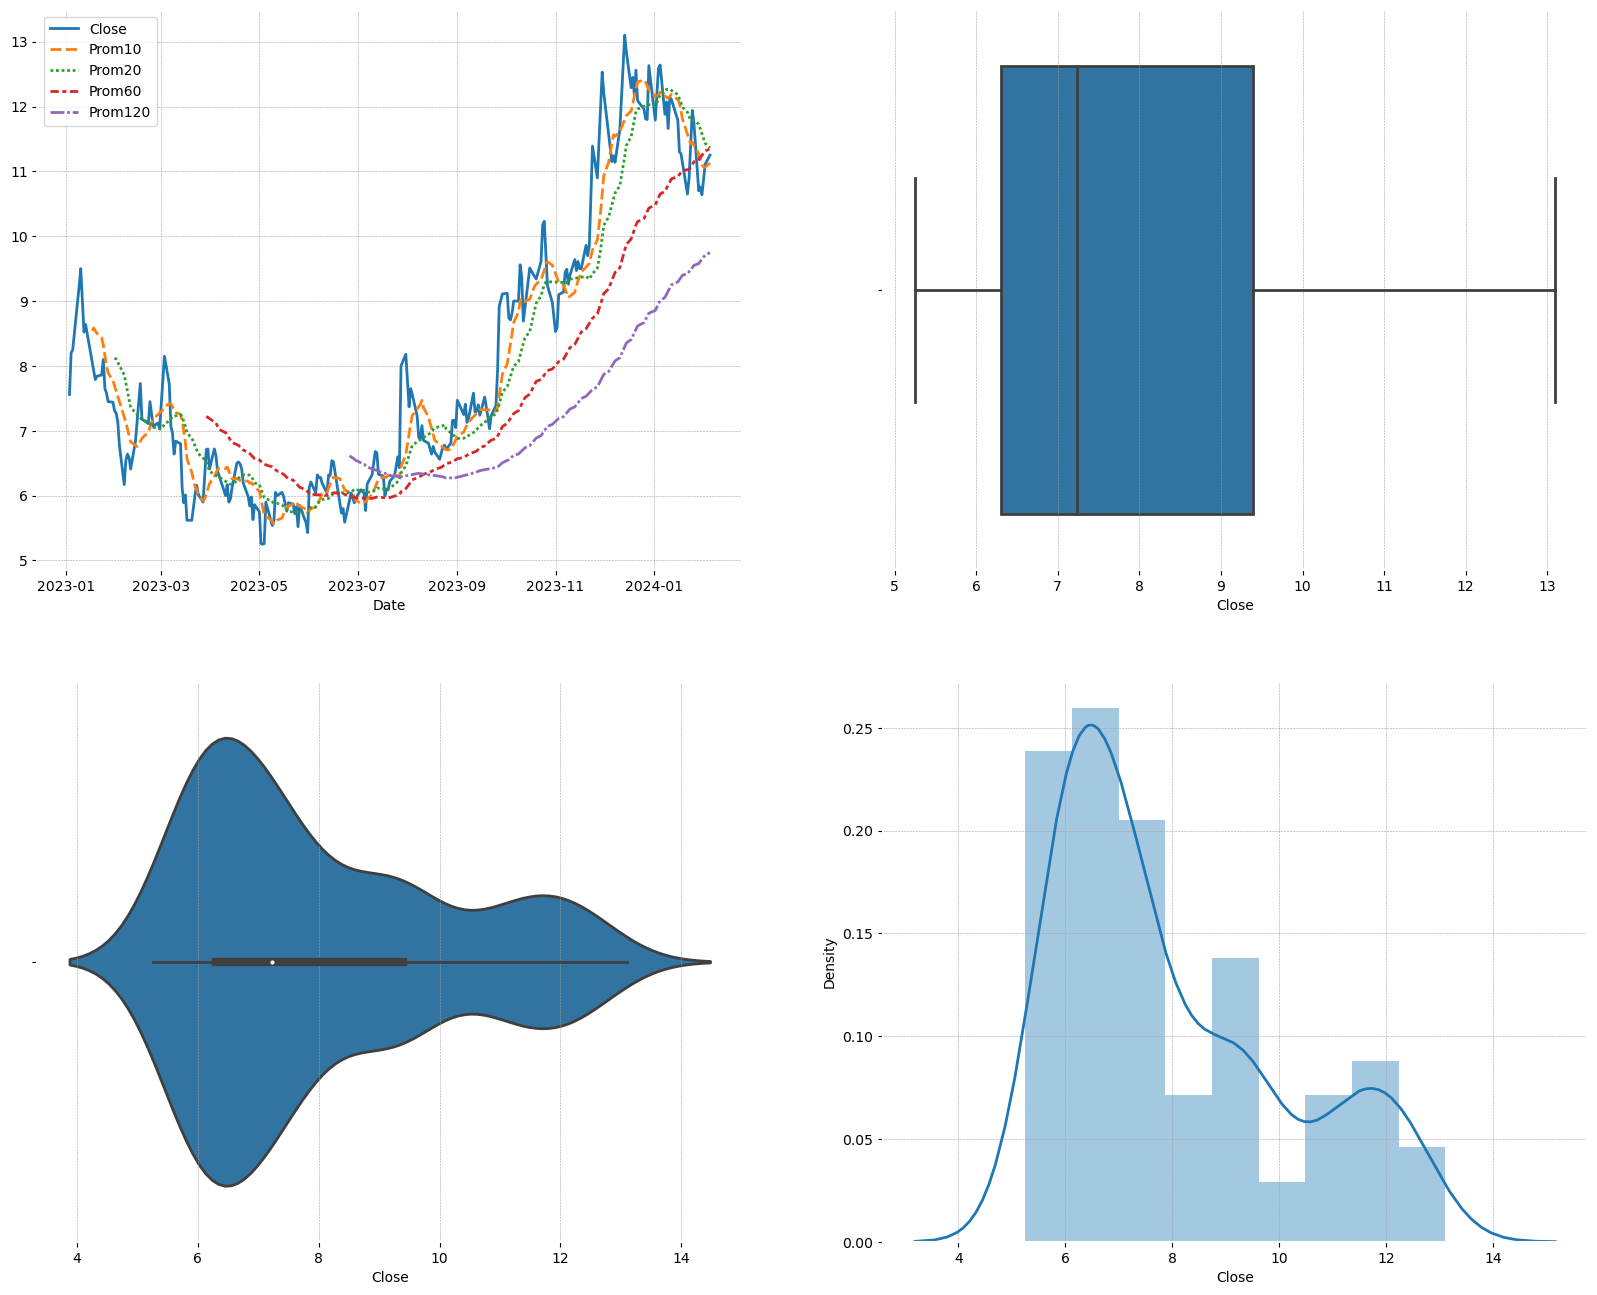

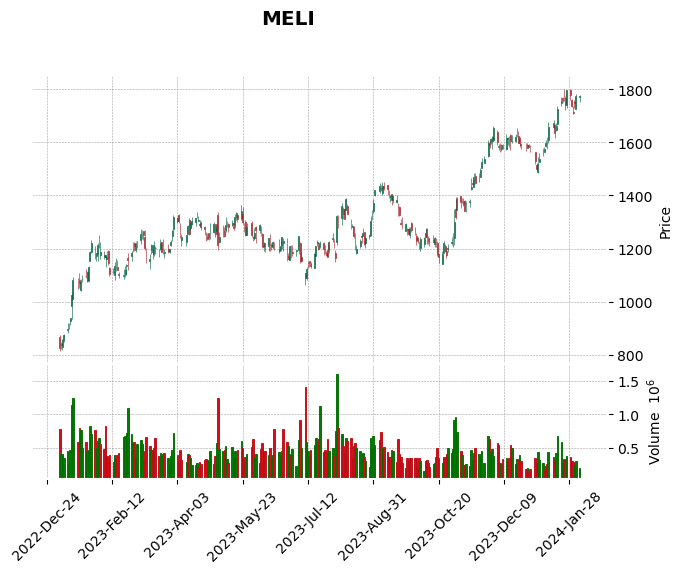

C:\Users\galle\AppData\Local\Temp\ipykernel_7124\2539240877.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(D1["Close"],ax=axes[1, 1])


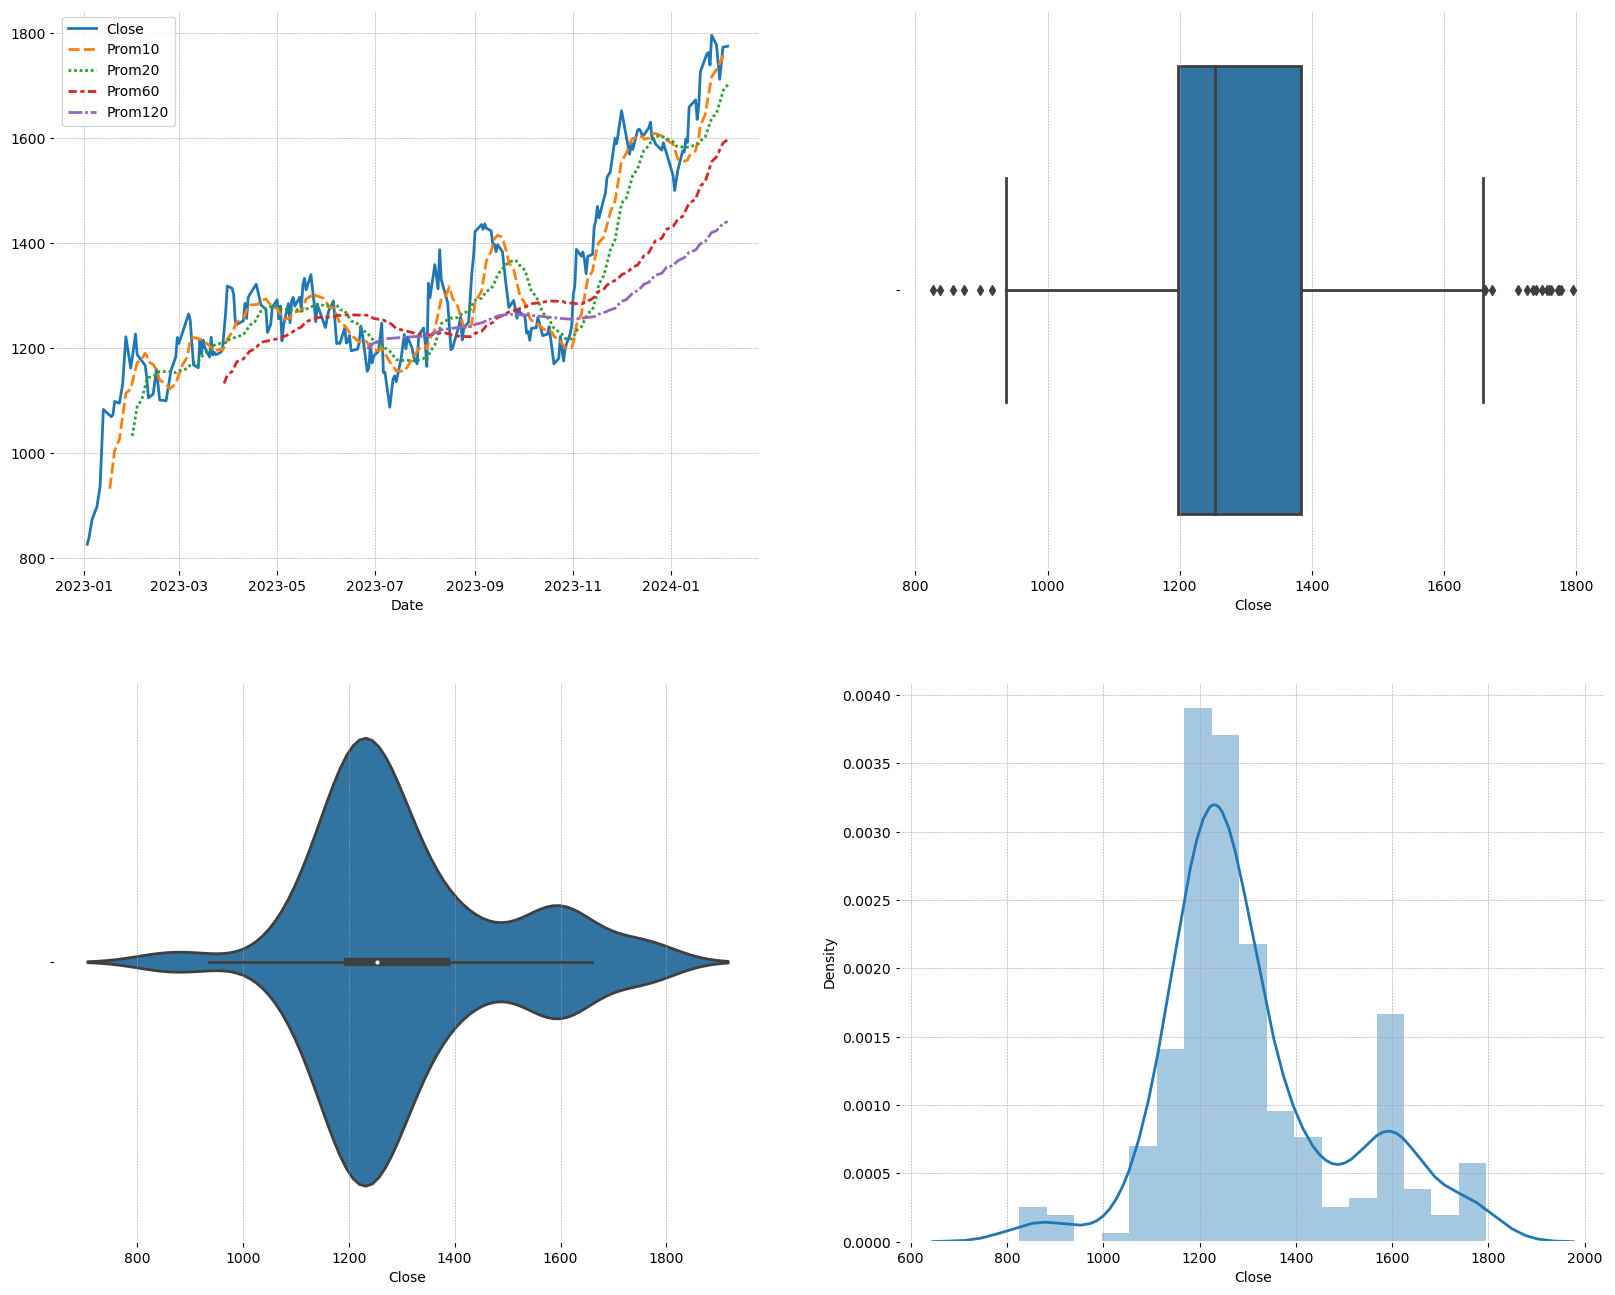

In [17]:
#Bucle para extraer la información en un periodo más corto, además de graficar la información en grafica de velas, 
#asi como su volumen, otro grafico para ver el precio de cierre y ver la tendencia con promedios móviles, así como otros
#graficos para visualizar la tendencia de los datos.

for i in Top_A:
    D1= yf.download(i, start="2023-01-01", end="2024-02-06")
    
    mpf.plot(D1, type='candle', volume=True, show_nontrading=True, title=i,style='charles')
    D1['Prom10']=D1['Close'].rolling(10).mean()
    D1['Prom20']=D1['Close'].rolling(20).mean()
    D1['Prom60']=D1['Close'].rolling(60).mean()
    D1['Prom120']=D1['Close'].rolling(120).mean()
    D2 = pd.DataFrame(D1, columns=['Close','Prom10','Prom20','Prom60','Prom120'])
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
    sns.lineplot(data=D2, ax=axes[0, 0])
    sns.boxplot(x=D1["Close"],ax=axes[0, 1])
    sns.violinplot(x=D1["Close"],ax=axes[1, 0])
    sns.distplot(D1["Close"],ax=axes[1, 1])
    
        

In [18]:
#Emplear la regresión lineal para el pronóstico del precio de cierre.

In [19]:
print(Top_A[0])

MARA


In [20]:
Top1= yf.download(Top_A[0], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [21]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [22]:
serie = Top1['Close']

In [23]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [25]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [26]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =0.35406702596418843
Pruebas: MSE =1.5794623647045207


,valor real,prediccion,diferencia
0,13.160000,13.017166,0.142834
1,13.820000,12.791150,1.028850
2,13.860000,13.822201,0.037799
3,15.320000,13.882193,1.437807
4,15.560000,14.679506,0.880494
...,...,...,...
147,18.520000,18.431211,0.088789
148,18.110001,18.768839,-0.658838
149,17.730000,18.950637,-1.220638
150,18.600000,17.982308,0.617692


Text(0.5, 1.0, 'MARA')

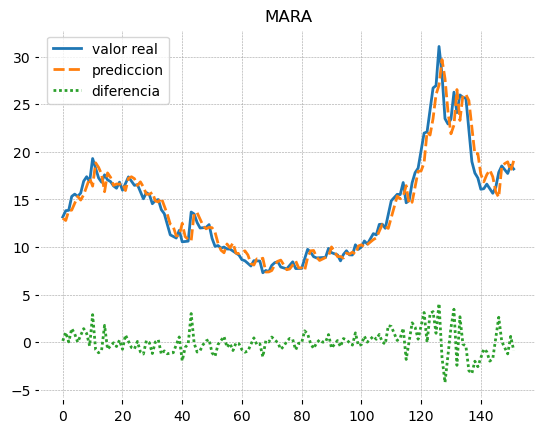

In [27]:
sns.lineplot(data=df_predicciones).set_title(Top_A[0])

In [28]:
#Esta línea solo fue para Comprobar que se esté cumpliendo lo de no tomar datos al azar.
Top1

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-01-03,3.580000,3.770000,3.280000,3.400000,3.400000,13014400
2023-01-04,3.500000,4.330000,3.480000,4.220000,4.220000,32367400
2023-01-05,4.110000,4.300000,3.890000,3.910000,3.910000,24923800
2023-01-06,3.940000,4.220000,3.710000,4.090000,4.090000,19314200
2023-01-09,4.260000,5.300000,4.200000,4.900000,4.900000,44884600
...,...,...,...,...,...,...
2024-01-30,18.440001,19.080000,17.830000,18.110001,18.110001,56458800
2024-01-31,17.459999,19.180000,17.270000,17.730000,17.730000,75527900
2024-02-01,17.760000,18.870001,17.139999,18.600000,18.600000,64373700


In [29]:
print(Top_A[1])

NVDA


In [30]:
Top2= yf.download(Top_A[1], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [31]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [32]:
serie = Top2['Close']

In [33]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [35]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [36]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =96.07148694658659
Pruebas: MSE =165.65969652242424


,valor real,prediccion,diferencia
0,411.170013,430.342950,-19.172937
1,408.220001,415.162919,-6.942917
2,423.019989,417.650725,5.369264
3,424.130005,438.509368,-14.379363
4,423.170013,428.629010,-5.458996
...,...,...,...
147,624.650024,619.592860,5.057165
148,627.739990,631.203671,-3.463680
149,615.270020,633.873189,-18.603170
150,630.270020,617.838303,12.431717


Text(0.5, 1.0, 'NVDA')

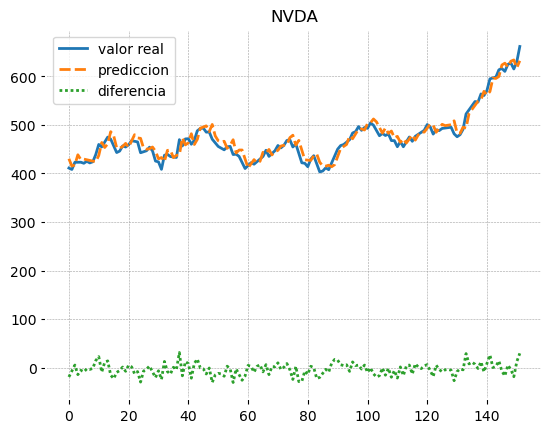

In [37]:
sns.lineplot(data=df_predicciones).set_title(Top_A[1])

In [38]:
print(Top_A[2])

TSLA


In [39]:
Top3= yf.download(Top_A[2], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [40]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [41]:
serie = Top3['Close']

In [42]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [44]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [45]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =35.87635422564892
Pruebas: MSE =71.39376952794957


,valor real,prediccion,diferencia
0,256.239990,246.405065,9.834925
1,257.500000,248.608513,8.891487
2,261.769989,252.495407,9.274582
3,279.820007,257.057104,22.762903
4,282.480011,266.200522,16.279489
...,...,...,...
147,190.929993,182.736555,8.193438
148,191.589996,185.549390,6.040607
149,187.289993,187.541645,-0.251652
150,188.860001,185.029207,3.830794


Text(0.5, 1.0, 'TSLA')

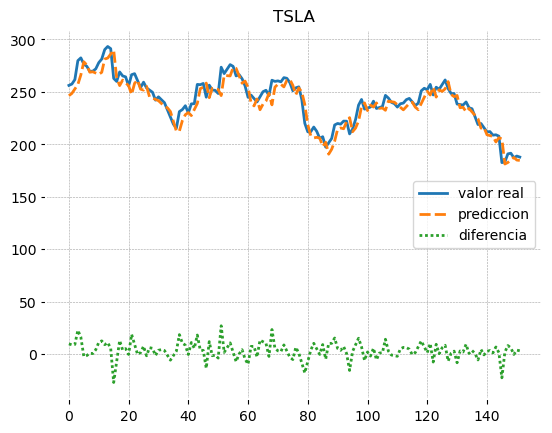

In [46]:
sns.lineplot(data=df_predicciones).set_title(Top_A[2])

In [47]:
print(Top_A[3])

AMD


In [48]:
Top4= yf.download(Top_A[3], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [49]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [50]:
serie = Top4['Close']

In [51]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [53]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [54]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =8.000441506894921
Pruebas: MSE =16.75894260603174


,valor real,prediccion,diferencia
0,110.169998,113.862337,-3.692339
1,111.239998,107.569998,3.670000
2,113.910004,107.786329,6.123674
3,115.820000,115.486999,0.333000
4,113.949997,110.912692,3.037305
...,...,...,...
147,177.830002,179.348790,-1.518788
148,172.059998,180.718043,-8.658045
149,167.690002,166.989431,0.700571
150,170.479996,169.896231,0.583764


Text(0.5, 1.0, 'AMD')

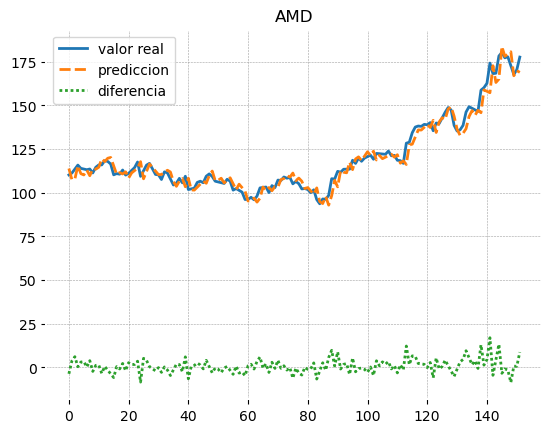

In [55]:
sns.lineplot(data=df_predicciones).set_title(Top_A[3])

In [56]:
print(Top_A[4])

RIOT


In [57]:
Top5= yf.download(Top_A[4], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [58]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [59]:
serie = Top5['Close']

In [60]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [61]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [62]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [63]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =0.35149976625306084
Pruebas: MSE =0.7055793740599278


,valor real,prediccion,diferencia
0,11.54,11.443746,0.096254
1,11.66,11.201769,0.458231
2,11.82,11.682254,0.137746
3,13.35,11.547449,1.802551
4,13.59,12.922969,0.667032
...,...,...,...
147,11.55,11.066886,0.483114
148,11.34,11.442752,-0.102752
149,10.90,11.094736,-0.194736
150,11.30,10.953445,0.346555


Text(0.5, 1.0, 'RIOT')

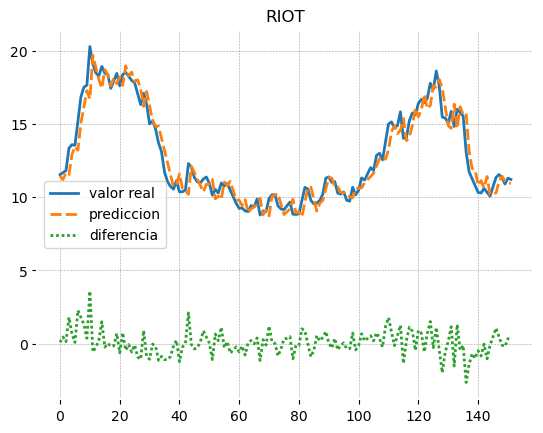

In [64]:
sns.lineplot(data=df_predicciones).set_title(Top_A[4])

In [65]:
print(Top_A[5])

GME


In [66]:
Top6= yf.download(Top_A[5], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [67]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [68]:
serie = Top6['Close']

In [69]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [70]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [71]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [72]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =0.9924042534441698
Pruebas: MSE =1.0903634779500848


,valor real,prediccion,diferencia
0,24.98,22.327458,2.652541
1,24.90,24.438788,0.461212
2,24.25,24.295823,-0.045823
3,24.91,23.969745,0.940255
4,23.90,24.835480,-0.935480
...,...,...,...
147,14.78,15.165779,-0.385779
148,14.55,15.782776,-1.232776
149,14.23,15.525032,-1.295032
150,14.42,15.230238,-0.810238


Text(0.5, 1.0, 'GME')

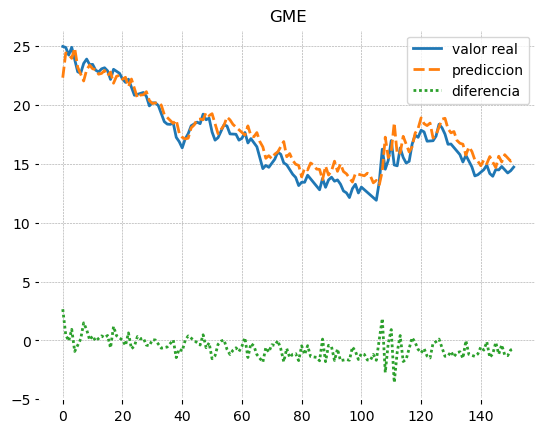

In [73]:
sns.lineplot(data=df_predicciones).set_title(Top_A[5])

In [74]:
print(Top_A[6])

NFLX


In [75]:
Top7= yf.download(Top_A[6], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [76]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [77]:
serie = Top7['Close']

In [78]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [79]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [80]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [81]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =51.085404139631024
Pruebas: MSE =171.24772783058737


,valor real,prediccion,diferencia
0,429.839996,411.316390,18.523607
1,428.239990,422.372352,5.867638
2,440.489990,415.844495,24.645495
3,441.440002,429.588795,11.851207
4,445.899994,428.816818,17.083176
...,...,...,...
147,575.789978,555.803483,19.986495
148,562.849976,566.135706,-3.285730
149,564.109985,556.429612,7.680374
150,567.510010,568.691654,-1.181644


Text(0.5, 1.0, 'NFLX')

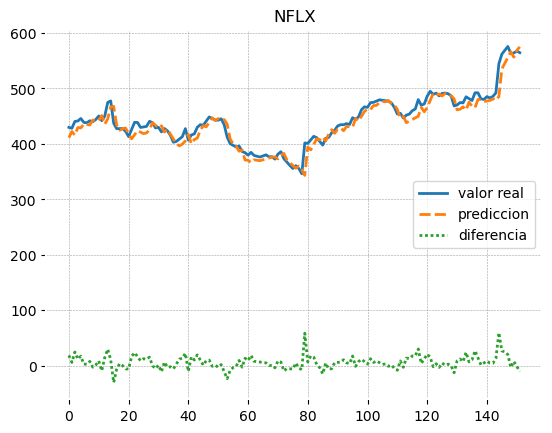

In [82]:
sns.lineplot(data=df_predicciones).set_title(Top_A[6])

In [83]:
print(Top_A[7])

SHOP


In [84]:
Top8= yf.download(Top_A[7], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [85]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [86]:
serie = Top8['Close']

In [87]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [88]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [89]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [90]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =3.6293319011947043
Pruebas: MSE =4.39579947559282


,valor real,prediccion,diferencia
0,64.620003,63.683455,0.936548
1,63.759998,64.428679,-0.668680
2,64.599998,63.830164,0.769835
3,64.849998,64.869978,-0.019980
4,64.440002,65.044652,-0.604649
...,...,...,...
147,83.540001,82.469552,1.070449
148,82.330002,84.343609,-2.013607
149,80.070000,81.653470,-1.583471
150,76.720001,79.725465,-3.005463


Text(0.5, 1.0, 'SHOP')

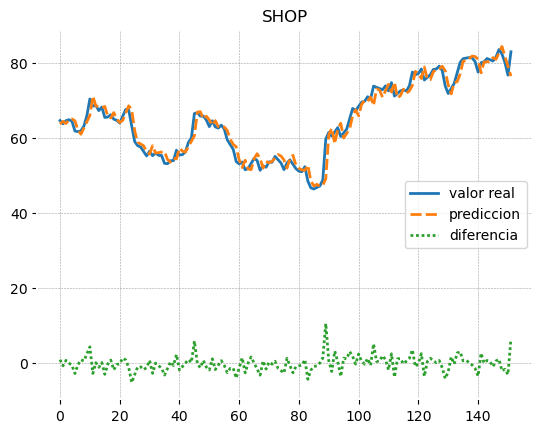

In [91]:
sns.lineplot(data=df_predicciones).set_title(Top_A[7])

In [92]:
print(Top_A[8])

TAL


In [93]:
Top9= yf.download(Top_A[8], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [94]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [95]:
serie = Top9['Close']

In [96]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [97]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [98]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [99]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =0.06195038744196937
Pruebas: MSE =0.32230299532086465


,valor real,prediccion,diferencia
0,5.98,5.948735,0.031265
1,5.89,5.964038,-0.074038
2,5.96,5.827815,0.132185
3,6.09,6.116923,-0.026922
4,6.04,6.070392,-0.030392
...,...,...,...
147,10.70,11.020267,-0.320268
148,10.76,10.290633,0.469367
149,10.64,10.481816,0.158184
150,10.94,10.317003,0.622997


Text(0.5, 1.0, 'TAL')

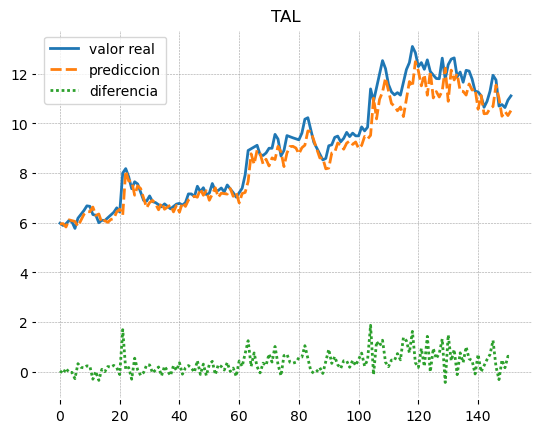

In [100]:
sns.lineplot(data=df_predicciones).set_title(Top_A[8])

In [101]:
print(Top_A[9])

MELI


In [102]:
Top10= yf.download(Top_A[9], start="2023-01-01", end="2024-02-06")

[*********************100%***********************]  1 of 1 completed


In [103]:
def transformarSerieADataset(serie, elementosPorMuestra):
    dataset = None
    salidasDataset = None
    for counter in range (len(serie)-elementosPorMuestra-1):        
        muestra = np.array([serie[counter:counter+elementosPorMuestra]])        
        salida = np.array([serie[counter+elementosPorMuestra]])
        if dataset is None:
            dataset = muestra
        else:
            dataset = np.append(dataset,muestra,axis = 0)
        if salidasDataset is None:
            salidasDataset = salida    
        else:        
            salidasDataset = np.append(salidasDataset,salida)
    return dataset, salidasDataset

In [104]:
serie = Top10['Close']

In [105]:
X, Y = transformarSerieADataset(serie, elementosPorMuestra = 20)

In [106]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.6,shuffle=False, random_state=10)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(101, 20)
(152, 20)
(101,)
(152,)


In [107]:
lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression()

In [108]:
y_train_predict = lin_model.predict(X_train)
MSE = mean_squared_error(Y_train,y_train_predict)
print("Entrenamiento: MSE ="+str(MSE))

y_test_predict = lin_model.predict(X_test)
MSE = (mean_squared_error(Y_test, y_test_predict))
print("Pruebas: MSE ="+str(MSE))

df_predicciones = pd.DataFrame({'valor real':Y_test, 'prediccion':y_test_predict, 'diferencia':Y_test-y_test_predict})
df_predicciones = df_predicciones
df_predicciones.head(268)

Entrenamiento: MSE =528.1654318878121
Pruebas: MSE =2189.862591037416


,valor real,prediccion,diferencia
0,1207.689941,1170.153755,37.536187
1,1171.449951,1241.270957,-69.821006
2,1184.599976,1199.450421,-14.850445
3,1193.750000,1177.531180,16.218820
4,1247.359985,1208.769147,38.590838
...,...,...,...
147,1777.430054,1722.405170,55.024884
148,1735.300049,1706.005136,29.294913
149,1711.810059,1665.132749,46.677310
150,1748.280029,1653.706559,94.573471


Text(0.5, 1.0, 'MELI')

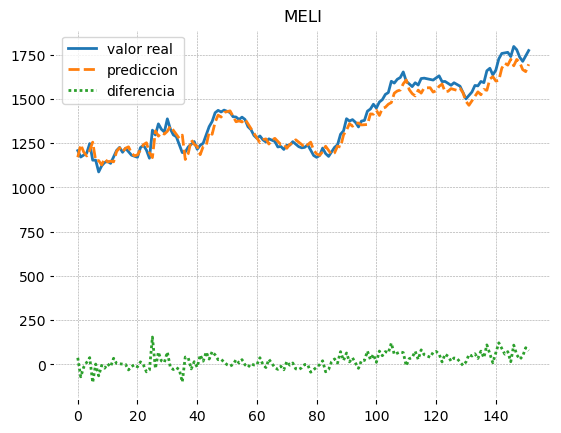

In [109]:
sns.lineplot(data=df_predicciones).set_title(Top_A[9])